# Phase 11 – Unsupervised Outputs

This notebook visualizes unsupervised outputs generated by the C++ ML Core practical workflow.

It reads exported CSV files only. It does **not** train models or reimplement model logic in Python.

Input files:

```txt
outputs/practical-exercises/unsupervised/metrics.csv
outputs/practical-exercises/unsupervised/projections.csv
outputs/practical-exercises/unsupervised/clustering_assignments.csv
```

Workflow:

```txt
PCA 2D projection
KMeans clustering
PCA + KMeans visualization-ready output
```

Dataset:

```txt
stock_ohlcv_engineered
```


## 1. Load exported outputs

The notebook is expected to be run from:

```txt
notebooks/practical-workflows/
```

so paths are resolved relative to the notebook location.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../../outputs/practical-exercises/unsupervised")

metrics_path = OUTPUT_DIR / "metrics.csv"
projections_path = OUTPUT_DIR / "projections.csv"
clustering_assignments_path = OUTPUT_DIR / "clustering_assignments.csv"

required_paths = [
    metrics_path,
    projections_path,
    clustering_assignments_path,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing required output file: {path}")

metrics = pd.read_csv(metrics_path)
projections = pd.read_csv(projections_path)
clustering_assignments = pd.read_csv(clustering_assignments_path)

print("metrics:", metrics.shape)
print("projections:", projections.shape)
print("clustering_assignments:", clustering_assignments.shape)


metrics: (6, 7)
projections: (1000, 9)
clustering_assignments: (2000, 8)


## 2. Metrics table

The metrics file contains PCA and KMeans summary values.

Expected metrics include:

```txt
explained_variance_ratio_1
explained_variance_ratio_2
inertia
iterations
```


In [2]:
metrics


,run_id,workflow,dataset,model,split,metric,value
0,pca_2d_baseline,unsupervised,stock_ohlcv_engineered,PCA,full,explained_variance_ratio_1,0.348891
1,pca_2d_baseline,unsupervised,stock_ohlcv_engineered,PCA,full,explained_variance_ratio_2,0.288775
2,kmeans_baseline,unsupervised,stock_ohlcv_engineered,KMeans,full,inertia,2927.170904
3,kmeans_baseline,unsupervised,stock_ohlcv_engineered,KMeans,full,iterations,14.000000
4,pca_kmeans_baseline,unsupervised,stock_ohlcv_engineered,PCA+KMeans,full,inertia,1134.654216
5,pca_kmeans_baseline,unsupervised,stock_ohlcv_engineered,PCA+KMeans,full,iterations,20.000000


## 3. PCA explained variance

For PCA, explained variance ratio shows how much variance is retained by each principal component.

Higher explained variance means that the component captures more structure from the original feature space.


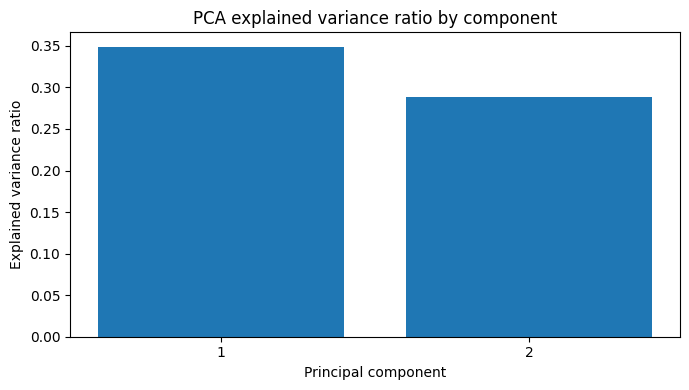

,run_id,workflow,dataset,model,split,metric,value,component
0,pca_2d_baseline,unsupervised,stock_ohlcv_engineered,PCA,full,explained_variance_ratio_1,0.348891,1
1,pca_2d_baseline,unsupervised,stock_ohlcv_engineered,PCA,full,explained_variance_ratio_2,0.288775,2


In [3]:
pca_metrics = metrics[metrics["model"] == "PCA"].copy()

pca_variance = pca_metrics[
    pca_metrics["metric"].str.startswith("explained_variance_ratio_")
].copy()

pca_variance["component"] = (
    pca_variance["metric"]
    .str.replace("explained_variance_ratio_", "", regex=False)
    .astype(int)
)

pca_variance = pca_variance.sort_values("component")

plt.figure(figsize=(7, 4))
plt.bar(pca_variance["component"].astype(str), pca_variance["value"])
plt.title("PCA explained variance ratio by component")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.tight_layout()
plt.show()

pca_variance


## 4. PCA 2D projection

The projections file contains:

```txt
component_1
component_2
```

This plot shows the data projected into two dimensions by PCA.


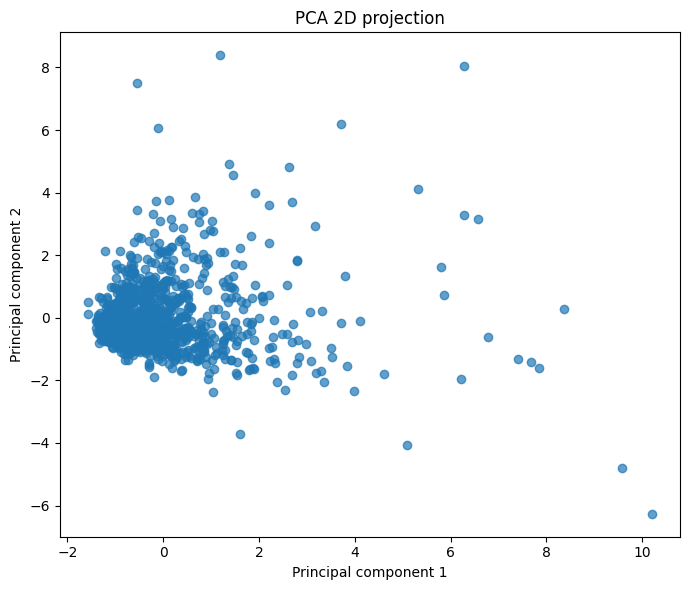

In [4]:
pca_projection = projections[projections["method"] == "PCA"].copy()

plt.figure(figsize=(7, 6))
plt.scatter(
    pca_projection["component_1"],
    pca_projection["component_2"],
    alpha=0.7,
)
plt.title("PCA 2D projection")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.tight_layout()
plt.show()


## 5. KMeans clustering assignments

The clustering assignments file contains rows for:

```txt
KMeans
PCA+KMeans
```

The plain `KMeans` run clusters the standardized original feature space.

The `PCA+KMeans` run clusters the 2D PCA projection.


In [5]:
clustering_assignments.head()


,run_id,row_id,workflow,dataset,method,split,cluster,label_reference
0,kmeans_baseline,0,unsupervised,stock_ohlcv_engineered,KMeans,full,2,NaN
1,kmeans_baseline,1,unsupervised,stock_ohlcv_engineered,KMeans,full,1,NaN
2,kmeans_baseline,2,unsupervised,stock_ohlcv_engineered,KMeans,full,1,NaN
3,kmeans_baseline,3,unsupervised,stock_ohlcv_engineered,KMeans,full,1,NaN
4,kmeans_baseline,4,unsupervised,stock_ohlcv_engineered,KMeans,full,2,NaN


## 6. Cluster count comparison

This section shows how many samples were assigned to each cluster for each clustering method.


In [6]:
cluster_counts = (
    clustering_assignments
    .groupby(["method", "cluster"])
    .size()
    .reset_index(name="count")
)

cluster_counts


,method,cluster,count
0,KMeans,0,137
1,KMeans,1,144
2,KMeans,2,704
3,KMeans,3,15
4,PCA+KMeans,0,144
5,PCA+KMeans,1,140
6,PCA+KMeans,2,702
7,PCA+KMeans,3,14


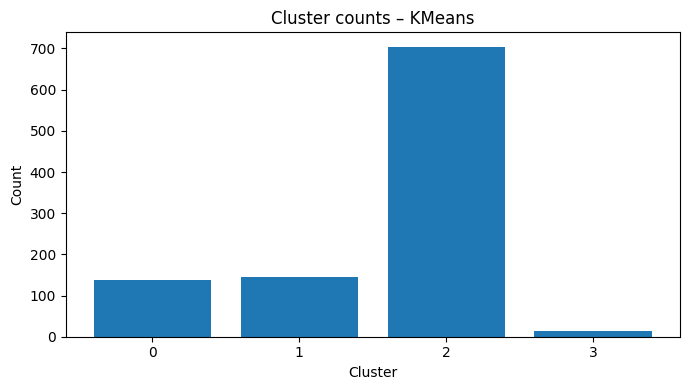

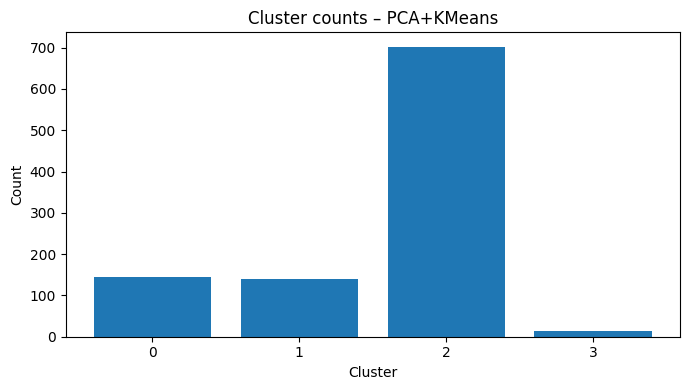

In [7]:
for method_name, subset in cluster_counts.groupby("method"):
    plt.figure(figsize=(7, 4))
    plt.bar(subset["cluster"].astype(str), subset["count"])
    plt.title(f"Cluster counts – {method_name}")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 7. KMeans clusters visualized in PCA space

This plot joins the PCA projection with the `KMeans` assignments.

This answers:

```txt
How do clusters learned in the original feature space appear in PCA 2D space?
```


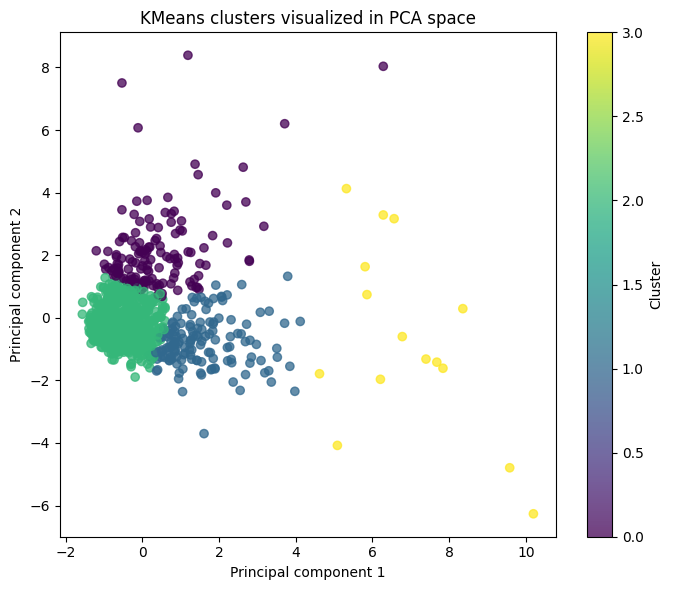

In [8]:
def join_projection_with_clusters(
    projection_frame: pd.DataFrame,
    cluster_frame: pd.DataFrame,
    method_name: str,
) -> pd.DataFrame:
    selected_clusters = cluster_frame[cluster_frame["method"] == method_name].copy()

    joined = projection_frame.merge(
        selected_clusters[["row_id", "cluster"]],
        on="row_id",
        how="inner",
    )

    if joined.empty:
        raise ValueError(f"No joined rows for method: {method_name}")

    return joined


kmeans_in_pca_space = join_projection_with_clusters(
    pca_projection,
    clustering_assignments,
    "KMeans",
)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    kmeans_in_pca_space["component_1"],
    kmeans_in_pca_space["component_2"],
    c=kmeans_in_pca_space["cluster"],
    alpha=0.75,
)
plt.title("KMeans clusters visualized in PCA space")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


## 8. PCA + KMeans combined plot

This plot uses the `PCA+KMeans` assignments.

This answers:

```txt
What clusters are produced when KMeans is applied directly to the PCA 2D representation?
```


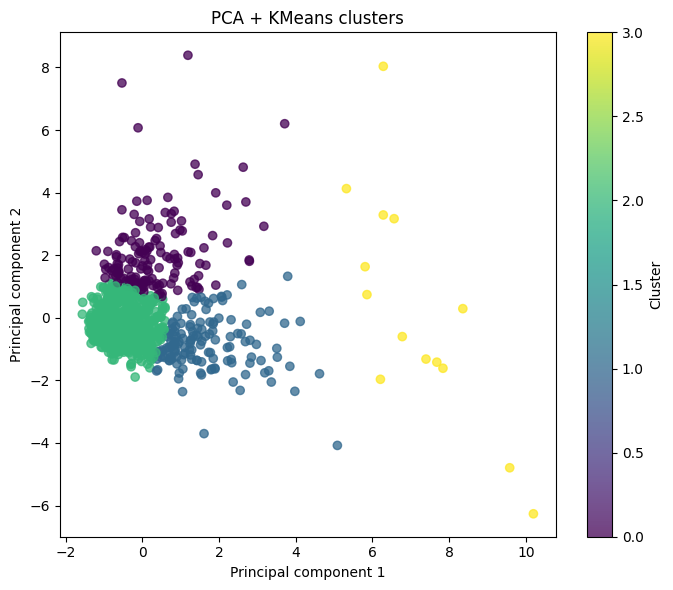

In [9]:
pca_kmeans_in_pca_space = join_projection_with_clusters(
    pca_projection,
    clustering_assignments,
    "PCA+KMeans",
)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    pca_kmeans_in_pca_space["component_1"],
    pca_kmeans_in_pca_space["component_2"],
    c=pca_kmeans_in_pca_space["cluster"],
    alpha=0.75,
)
plt.title("PCA + KMeans clusters")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


## 9. Compare KMeans vs PCA+KMeans assignments

This table compares how often pairs of cluster assignments occur between:

```txt
KMeans
PCA+KMeans
```

Cluster IDs are arbitrary, so this table does not mean cluster `0` has the same semantic meaning across methods. It only helps compare assignment structure.


In [10]:
kmeans_assignments = clustering_assignments[
    clustering_assignments["method"] == "KMeans"
][["row_id", "cluster"]].rename(columns={"cluster": "kmeans_cluster"})

pca_kmeans_assignments = clustering_assignments[
    clustering_assignments["method"] == "PCA+KMeans"
][["row_id", "cluster"]].rename(columns={"cluster": "pca_kmeans_cluster"})

assignment_comparison = kmeans_assignments.merge(
    pca_kmeans_assignments,
    on="row_id",
    how="inner",
)

comparison_table = pd.crosstab(
    assignment_comparison["kmeans_cluster"],
    assignment_comparison["pca_kmeans_cluster"],
    rownames=["KMeans cluster"],
    colnames=["PCA+KMeans cluster"],
)

comparison_table


PCA+KMeans cluster,0,1,2,3
KMeans cluster,,,,
0,136,0,0,1
1,1,138,5,0
2,7,0,697,0
3,0,2,0,13


## 10. Interpretation notes

This notebook is for visualization only.

Important interpretation rules:

```txt
PCA:
  shows a compressed 2D view of high-dimensional feature structure

KMeans:
  assigns samples to clusters by minimizing distance to centroids

PCA + KMeans:
  clusters the compressed representation, which may be easier to visualize but may discard some information
```

Lower KMeans inertia means more compact clusters, but it does not automatically mean the clusters are semantically meaningful.

The PCA 2D plot is useful for exploration, not proof of true market regimes.
